<a href="https://colab.research.google.com/github/Jude-Ufoh/Pytorch/blob/main/Pytorch1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi


Sat Mar 28 21:49:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print(torch.__version__)


2.10.0+cu128


In [ ]:
x = torch.tensor([[1, 2], [3,4],[6,5]])
print(x.ndim)
x[0]

2


tensor([1, 2])

### Random Tensors

In [ ]:
x= torch.rand(3,2,2)
x

tensor([[[0.9065, 0.4503],
         [0.8467, 0.5637]],

        [[0.9857, 0.0190],
         [0.5784, 0.5097]],

        [[0.5495, 0.3887],
         [0.7597, 0.3721]]])

### zeros and ones

In [ ]:
zeros = torch.zeros(3,4)
ones = torch.ones(3,4)
zeros, ones

(tensor([[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]),
 tensor([[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]))

### Creating a tensor range
A tensor range is created using functions like arange() (step-based) or linspace() (evenly spaced values)

In [ ]:
# creating a range

y= torch.arange(2,5,1)
y

tensor([2, 3, 4])

### Getting information from tensors

In [ ]:
z= torch.rand(1,3,4)
z

tensor([[[0.8271, 0.4550, 0.0620, 0.3701],
         [0.0285, 0.4166, 0.2971, 0.9791],
         [0.8234, 0.1387, 0.2125, 0.3031]]])

In [ ]:
z.dtype
z.size()

torch.Size([1, 3, 4])

## Tensor Aggregation

In [ ]:
x = torch.arange(0,100,5)
x.size()

torch.Size([20])

In [ ]:
x.type(torch.float32).mean()

tensor(47.5000)

In [ ]:
torch.mean(x.type(torch.float32))

tensor(47.5000)

In [ ]:
y= torch.rand(3,6)
y

tensor([[0.6694, 0.2798, 0.1908, 0.6810, 0.9873, 0.3766],
        [0.6286, 0.5529, 0.9212, 0.9573, 0.8470, 0.0084],
        [0.7681, 0.2617, 0.5459, 0.9647, 0.9741, 0.5891]])

In [ ]:
y.argmin()

tensor(11)

In [ ]:
z=torch.arange(1,8)
z

tensor([1, 2, 3, 4, 5, 6, 7])

In [ ]:
z1=z.reshape(1,7)
z1.shape


torch.Size([1, 7])

In [ ]:
z_stacked = torch.stack([z,z,z,z], dim=1)
z_stacked

tensor([[1, 1, 1, 1],
        [2, 2, 2, 2],
        [3, 3, 3, 3],
        [4, 4, 4, 4],
        [5, 5, 5, 5],
        [6, 6, 6, 6],
        [7, 7, 7, 7]])

In [ ]:
a= torch.rand(1,2,1,4)
a

tensor([[[[0.1934, 0.7021, 0.4834, 0.5665]],

         [[0.7355, 0.8022, 0.8738, 0.9943]]]])

In [ ]:
b = torch.arange(1, 10).reshape(1, 3, 3)
b, b.shape



(tensor([[[1, 2, 3],
          [4, 5, 6],
          [7, 8, 9]]]),
 torch.Size([1, 3, 3]))

In [ ]:
b[:,1,2]

tensor([6])

In [ ]:
import numpy as np

a = np.random.rand(2, 3)
t = torch.from_numpy(a)

In [ ]:
a[0, 0] = 999
print(t)

tensor([[9.9900e+02, 7.8951e-01, 9.1670e-01],
        [1.6736e-01, 6.7028e-01, 5.1550e-01]], dtype=torch.float64)


## Pytorch Workflow (Linear regression)

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
#checking the version of pytorch
torch.__version__

'2.10.0+cu128'

# Getting Data

In [ ]:
# we will use a simple regression formula to create single features and single labels
# formula y =mX + C where m= Weight = 0.7 and C= bias= 0.3 and y =label, X = features
# using pytorch to create the values of X starting from 0, and ending at 1 with increament of 0.02 and corresponding values of y
X= torch.arange(0,1,0.02).unsqueeze(dim=1)

y= 0.7*X + 0.3

X[:10], y[:10]


In [11]:
# Splitting the data into Training (80%) and testing sets (20%)
splitting_factor = int(0.8*len(X))

#Using the splitting factor to partition the the X and y data
X_train, y_train = X[:splitting_factor], y[:splitting_factor]
X_test, y_test = X[splitting_factor:], y[splitting_factor:]


In [25]:
# Creatin a function to visualise our data
def plot_data(train_features= X_train,
              train_labels=y_train,
              test_features=X_test,
              test_labels=y_test,
              predictions=None):
  """
  Plots training data, test data and compares predictions
  """
  plt.figure(figsize=(8,5))
  # Plot training data in  blue
  plt.scatter(train_features, train_labels, c="b", s=4, label="Training data")
  # Plot test data in green
  plt.scatter(test_features, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the prediction in red(if predictions were made on the test)
    plt.scatter(test_features, predictions, c="r", s=4, label="Predictions")
  # Show the legend
  plt.legend(prop={"size": 14})
  plt.show()

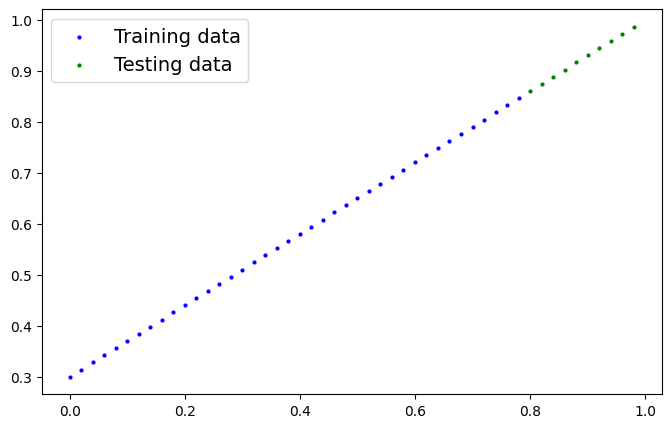

In [26]:
plot_data()

In [30]:
# Creating a Linear Regression model class
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights =nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
  # Forward method to define the computation in the model
  def forward(self, x: torch.Tensor) ->torch.Tensor:
    return self.weights * x + self.bias
